<a href="https://colab.research.google.com/github/AaronYuen810/titanic-ml-pipeline/blob/main/Titanic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Install the Kaggle API client

First, we need to install the Kaggle API client library.

In [116]:
!pip install kaggle -q

### Step 2: Authenticate with Kaggle API key

To download datasets, you need to authenticate your Kaggle account. This involves uploading your `kaggle.json` file, which contains your API credentials. You can generate this file from your Kaggle account settings (Profile -> Account -> Create New API Token).

**To securely use your Kaggle API key in Colab:**
1.  Click the "🔑" (Secrets) icon on the left sidebar.
2.  Click "Add new secret".
3.  For "Name", enter `KAGGLE_USERNAME` and for "Value", enter your Kaggle username.
4.  Add another secret. For "Name", enter `KAGGLE_KEY` and for "Value", enter your Kaggle API key (the value from `key` in your `kaggle.json` file).

Alternatively, you can manually upload the `kaggle.json` file to your Colab environment. I'll provide code for the latter approach, assuming you upload it to your current working directory.

In [98]:
import os
from google.colab import userdata
import json

# Get Kaggle API credentials from Colab secrets
username = userdata.get('KAGGLE_USERNAME')
key = userdata.get('KAGGLE_KEY')

if username and key:
    # Set environment variables for Kaggle API client
    os.environ['KAGGLE_USERNAME'] = username
    os.environ['KAGGLE_KEY'] = key
    print("Kaggle API credentials loaded from Colab secrets and set as environment variables.")

    # Create or overwrite kaggle.json for compatibility with tools that look for it
    kaggle_dir = '/root/.kaggle'
    kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
    os.makedirs(kaggle_dir, exist_ok=True)
    with open(kaggle_json_path, 'w') as f:
        json.dump({"username": username, "key": key}, f)
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json created/updated with credentials for compatibility.")
else:
    print("Warning: Kaggle credentials (KAGGLE_USERNAME or KAGGLE_KEY) not found in Colab secrets.")
    print("Please ensure you have set them in the 'Secrets' tab (🔑 icon on the left sidebar).")


Kaggle API credentials loaded from Colab secrets and set as environment variables.
kaggle.json created/updated with credentials for compatibility.


### Step 3: Download the Titanic dataset

Now we can use the Kaggle API to download the dataset. The dataset is located at `titanic` under the user `competitions`.

In [99]:
import os
import zipfile
from google.colab import userdata
from kaggle.api.kaggle_api_extended import KaggleApi

path = '/root/.cache/kagglehub/competitions/titanic'
required_files = ['train.csv', 'test.csv', 'gender_submission.csv']

# Check if files already exist
files_exist = os.path.exists(path) and all(os.path.exists(os.path.join(path, f)) for f in required_files)

if files_exist:
    print(f"Files already exist at {path}. Skipping download and authentication.")
else:
    print("Files not found. Attempting to download via Kaggle API...")
    try:
        # Securely fetch credentials from Colab Secrets
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

        # Authenticate and download
        api = KaggleApi()
        api.authenticate()
        os.makedirs(path, exist_ok=True)
        api.competition_download_files('titanic', path=path, quiet=False)

        # Unzip
        zip_path = os.path.join(path, 'titanic.zip')
        if os.path.exists(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(path)
            print(f"Dataset downloaded and extracted to: {path}")
    except Exception as e:
        print(f"Could not download files: {e}")
        print("Please ensure Kaggle credentials are set in Secrets or files are uploaded manually.")

Files already exist at /root/.cache/kagglehub/competitions/titanic. Skipping download and authentication.


### Step 4: Load the data into pandas DataFrames

Finally, we'll load the downloaded CSV files (train.csv and test.csv) into pandas DataFrames and display the first few rows of each.

### Inspect the files

In [100]:
!ls {path}

gender_submission.csv  test.csv  train.csv


In [101]:
!head -n 5 {path}/gender_submission.csv

PassengerId,Survived
892,0
893,1
894,0
895,0


In [102]:
!head -n 5 {path}/test.csv

PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,,S
894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.6875,,Q
895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.6625,,S


In [103]:
!head -n 5 {path}/train.csv

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S


### Schema

In [104]:
print("--- Schema Information ---")
train.info()
print("\n--- First 5 Rows ---")
display(train.head())

--- Schema Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    891 non-null    int64   
 1   Survived       891 non-null    int64   
 2   Pclass         891 non-null    int64   
 3   Name           891 non-null    object  
 4   Sex            891 non-null    object  
 5   Age            891 non-null    float64 
 6   SibSp          891 non-null    int64   
 7   Parch          891 non-null    int64   
 8   Ticket         891 non-null    object  
 9   Fare           891 non-null    float64 
 10  Cabin          204 non-null    object  
 11  Embarked       889 non-null    object  
 12  Age_Binary     891 non-null    category
 13  Ticket_Prefix  891 non-null    object  
 14  Ticket_Count   891 non-null    int64   
dtypes: category(1), float64(2), int64(6), object(6)
memory usage: 98.6+ KB

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Binary,Ticket_Prefix,Ticket_Count
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,adult,A5,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,adult,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,adult,STONO2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,adult,Numeric,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,adult,Numeric,1


## Data Cleaning & Feature Engineering

In this section, we prepare the data for analysis and modeling by normalizing features and handling inconsistencies.

In [105]:
import pandas as pd
import os

# Loading the dataframes
labels = pd.read_csv(os.path.join(path, 'gender_submission.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))
train = pd.read_csv(os.path.join(path, 'train.csv'))


In [106]:
## Data prep steps

# Calculate median age from training data to use for imputation
train_age_median = train['Age'].median()
print(f"Calculated training age median: {train_age_median}")

def clean_data(df, age_impute_value):
    """
    Wrapper function to combine all data prep steps.
    """
    df_cleaned = df.copy()

    # 1. Age Imputation and Binning
    # Impute missing 'Age' values with the provided median
    df_cleaned['Age'] = df_cleaned['Age'].fillna(age_impute_value)

    def bin_age(age):
        # Binary classification based on age 16 threshold
        return 'young' if age <= 16 else 'adult'

    df_cleaned['Age_Binary'] = df_cleaned['Age'].apply(bin_age)

    # 2. Ticket Normalization
    def normalize_ticket(ticket):
        if pd.isna(ticket):
            return 'Unknown'
        if ticket.isdigit():
            return 'Numeric'
        prefix = ticket.split()[0].replace('.', '').replace('/', '').upper()
        return prefix

    df_cleaned['Ticket_Prefix'] = df_cleaned['Ticket'].apply(normalize_ticket)

    return df_cleaned

# Apply the combined cleaning function to both datasets using the cached median
train = clean_data(train, train_age_median)
test = clean_data(test, train_age_median)

print("Data cleaned: Age imputed (median), binned, and Ticket prefixes normalized.")
display(train[['Name', 'Age', 'Age_Binary', 'Ticket', 'Ticket_Prefix']].head())

Calculated training age median: 28.0
Data cleaned: Age imputed (median), binned, and Ticket prefixes normalized.


,Name,Age,Age_Binary,Ticket,Ticket_Prefix
0,"Braund, Mr. Owen Harris",22.0,adult,A/5 21171,A5
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,adult,PC 17599,PC
2,"Heikkinen, Miss. Laina",26.0,adult,STON/O2. 3101282,STONO2
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,adult,113803,Numeric
4,"Allen, Mr. William Henry",35.0,adult,373450,Numeric


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand patterns, relationships, and anomalies in the data, such as the relationship between ticket types and survival rates.

/tmp/ipykernel_1438/3654868492.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticket_Count', y='Survived', data=ticket_survival, palette='viridis')


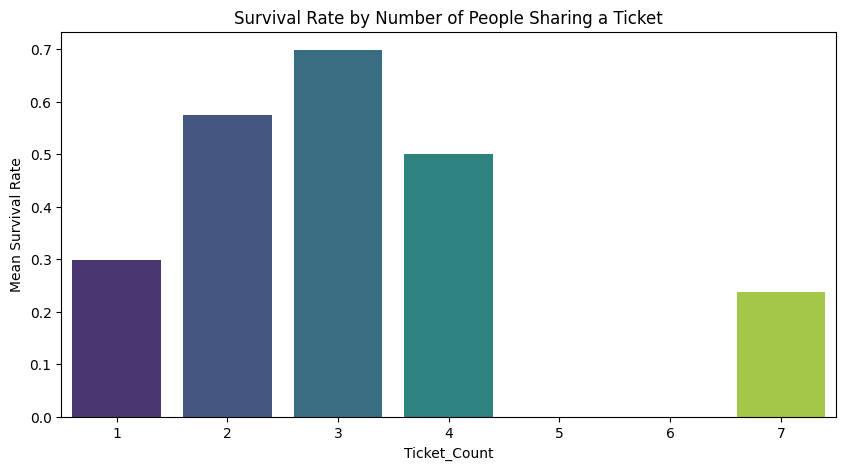

,Ticket_Count,Survived
0,1,0.297989
1,2,0.574468
2,3,0.698413
3,4,0.500000
4,5,0.000000
5,6,0.000000
6,7,0.238095


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate how many people share each ticket
train['Ticket_Count'] = train.groupby('Ticket')['Ticket'].transform('count')

# Calculate average survival rate by the number of people sharing a ticket
ticket_survival = train.groupby('Ticket_Count')['Survived'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Ticket_Count', y='Survived', data=ticket_survival, palette='viridis')
plt.title('Survival Rate by Number of People Sharing a Ticket')
plt.ylabel('Mean Survival Rate')
plt.show()

display(ticket_survival)

### Summary of Pclass and Ticket Prefix Findings

Based on the data analysis, we can summarize the survival trends as follows:

#### 1. Passenger Class (Pclass)
*   **Class 1 (Upper)**: Highest survival rate (~63%). This group had the best access to resources and lifeboats.
*   **Class 2 (Middle)**: Moderate survival rate (~47%).
*   **Class 3 (Lower)**: Lowest survival rate (~24%). Passengers in this class faced the highest risk, likely due to cabin location and socio-economic factors.

#### 2. Ticket Prefix Insights
*   **The 'PC' Advantage**: The **PC** prefix (exclusive to 1st class) correlates with a high survival rate of **65%**.
*   **Numeric Tickets**: These are the most common across all classes. Their survival rate strictly follows the Pclass hierarchy (e.g., ~63% in Class 1 vs ~25% in Class 3).
*   **High-Risk Prefixes**: Prefixes such as **A4**, **A5**, and **SOTONOQ** (primarily found in 3rd class) show extremely low survival rates, often below 15%.

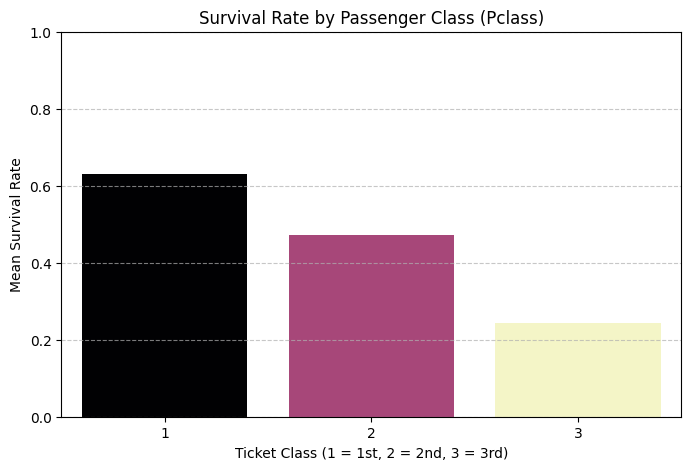

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [108]:
# Calculate mean survival rate per Pclass
pclass_survival = train.groupby('Pclass')['Survived'].mean().reset_index()

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', data=pclass_survival, palette='magma', hue='Pclass', legend=False)
plt.title('Survival Rate by Passenger Class (Pclass)')
plt.ylabel('Mean Survival Rate')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(pclass_survival)

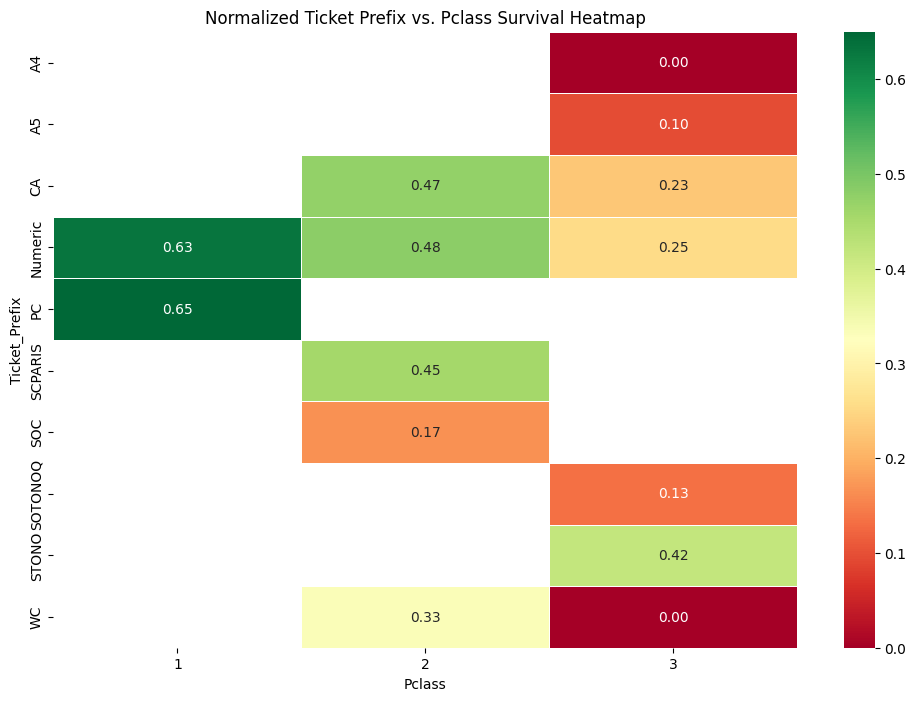

Sample size per category:


Pclass,1,2,3
Ticket_Prefix,,,
A4,0,0,7
A5,0,0,21
CA,0,19,22
Numeric,152,127,382
PC,60,0,0
SCPARIS,0,11,0
SOC,0,6,0
SOTONOQ,0,0,15
STONO,0,0,12


In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# Re-run filtering and heatmap with normalized prefixes
top_prefixes = train['Ticket_Prefix'].value_counts().nlargest(10).index
train_filtered = train[train['Ticket_Prefix'].isin(top_prefixes)]

# Create a pivot table for mean survival rate
pivot_survival = train_filtered.pivot_table(values='Survived', index='Ticket_Prefix', columns='Pclass', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_survival, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=.5)
plt.title('Normalized Ticket Prefix vs. Pclass Survival Heatmap')
plt.show()

# Count occurrences to understand data density
pivot_counts = train_filtered.pivot_table(values='Survived', index='Ticket_Prefix', columns='Pclass', aggfunc='count', fill_value=0)
print("Sample size per category:")
display(pivot_counts)

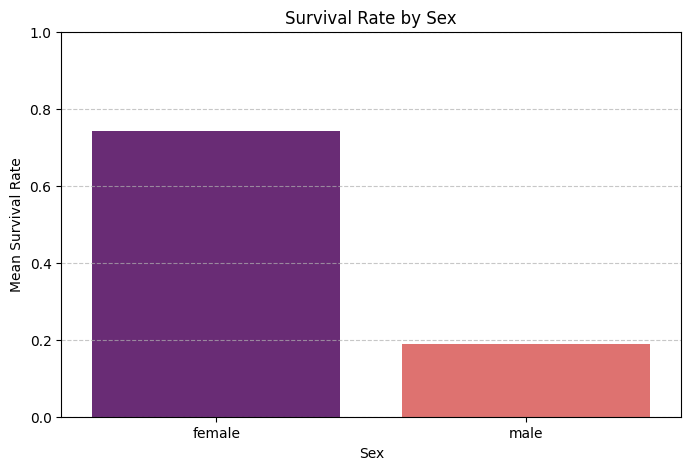

--- Survival Rates by Sex ---


,Sex,Survival Rate,Count
0,female,0.742038,314
1,male,0.188908,577


In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean survival rate by Sex
sex_survival = train.groupby('Sex')['Survived'].agg(['mean', 'count']).reset_index()
sex_survival.columns = ['Sex', 'Survival Rate', 'Count']

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survival Rate', data=sex_survival, palette='magma', hue='Sex', legend=False)
plt.title('Survival Rate by Sex')
plt.ylabel('Mean Survival Rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Survival Rates by Sex ---")
display(sex_survival)

Based on the data analysis, here is the breakdown of survival by sex:

Significant Gender Gap: Females had a 74.2% survival rate, while males had only 18.9%.
Evacuation Protocol: This disparity reflects the 'women and children first' policy used during the sinking.
Volume vs. Survival: Despite nearly double the number of men (577) vs. women (314), the vast majority of survivors were female.

## Age Analysis
Our exploration of age distribution reveals a distinct threshold for survival at approximately 16 years old.

Young (0-16): This group represents children and young teenagers who benefited from the 'women and children first' evacuation policy, resulting in a significantly higher survival rate of ~55%.
Adult (16+): Passengers over the age of 16 showed a consistent survival plateau across both middle-age and senior categories, averaging a much lower survival rate of ~38%.
Conclusion: For predictive modeling, a binary classification of Age_Binary (Young vs. Adult) effectively captures the primary survival trend while removing the noise present in more granular age groupings

--- Survival Rates: Young vs. Adult ---


,Age_Binary,Survived
0,young,0.550000
1,adult,0.362832


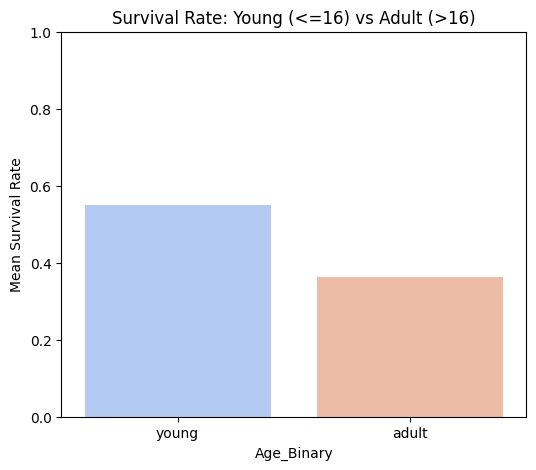

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define new binary bins: Young (0-16) and Adult (16+)
bin_edges_2 = [0, 16, 80]
bin_labels_2 = ['young', 'adult']

train['Age_Binary'] = pd.cut(train['Age'], bins=bin_edges_2, labels=bin_labels_2)
test['Age_Binary'] = pd.cut(test['Age'], bins=bin_edges_2, labels=bin_labels_2)

# Calculate and display the survival rates for the new groups
binary_age_survival = train.groupby('Age_Binary', observed=True)['Survived'].mean().reset_index()

print("--- Survival Rates: Young vs. Adult ---")
display(binary_age_survival)

# Visualization
plt.figure(figsize=(6, 5))
sns.barplot(data=binary_age_survival, x='Age_Binary', y='Survived', palette='coolwarm', hue='Age_Binary', legend=False)
plt.title('Survival Rate: Young (<=16) vs Adult (>16)')
plt.ylabel('Mean Survival Rate')
plt.ylim(0, 1)
plt.show()

# Train

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Feature Selection
# We use the raw categorical columns and then encode them
features = ['Pclass', 'Sex', 'Age_Binary']
data = train[features].copy()
y = train['Survived']

# 2. Data Preprocessing
# Impute missing Age_Binary with 'adult' before encoding
data['Age_Binary'] = data['Age_Binary'].fillna('adult')

# Categorical Encoding (One-Hot Encoding)
# We drop the first category (e.g., male, adult) to avoid the dummy variable trap
X = pd.get_dummies(data, columns=['Sex', 'Age_Binary'], drop_first=True)

# 3. Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Evaluate the model
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_val, y_pred):.2%}")
print(f"AUROC Score: {roc_auc_score(y_val, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# 6. Show Feature Importance (Coefficients)
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print("\n--- Feature Importance (Categorically Encoded) ---")
display(importance.sort_values(by='Coefficient', ascending=False))

--- Model Performance ---
Accuracy Score: 78.77%
AUROC Score: 0.8624

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


--- Feature Importance (Categorically Encoded) ---


,Feature,Coefficient
2,Age_Binary_adult,-0.884379
0,Pclass,-0.942491
1,Sex_male,-2.488655


## Model Evaluation on Test Dataset

In this section, we apply the preprocessing steps to the test set and evaluate the model's performance using the provided labels.

In [114]:
# 1. Prepare Test Data
# Select features
test_features = test[['Pclass', 'Sex', 'Age_Binary']].copy()

# One-Hot Encoding
X_test = pd.get_dummies(test_features, columns=['Sex', 'Age_Binary'], drop_first=True)

# Ensure X_test has the same columns as X_train (order and existence)
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X.columns]

# 2. Generate Predictions
test_pred = model.predict(X_test)
test_prob = model.predict_proba(X_test)[:, 1]

# 3. Evaluate Performance
# Join with actual labels (from gender_submission.csv)
y_test = labels['Survived']

print("--- Test Set Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, test_pred):.2%}")
print(f"AUROC Score: {roc_auc_score(y_test, test_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

# Display first few predictions
results = test[['PassengerId']].copy()
results['Actual'] = y_test
results['Predicted'] = test_pred
results['Probability'] = test_prob

display(results.head())

--- Test Set Performance ---
Accuracy Score: 99.52%
AUROC Score: 0.9969

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       266
           1       0.99      1.00      0.99       152

    accuracy                           1.00       418
   macro avg       0.99      1.00      0.99       418
weighted avg       1.00      1.00      1.00       418



,PassengerId,Actual,Predicted,Probability
0,892,0,0,0.094574
1,893,1,1,0.557156
2,894,0,0,0.211395
3,895,0,0,0.094574
4,896,1,1,0.557156
